In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf 
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, GlobalMaxPool1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
datapath = "../clean_data/re_clean_dataset.csv"
df = pd.read_csv(datapath)

In [4]:
df.isnull().sum()
df = df.dropna(subset=['cleaned_text'])

In [5]:
#70% training, 15% validation and 15% test

# X = df['stemmed_content'].values
X = df['text'].values
Y = df['sentiment'].values

X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size = 0.3, stratify = Y, random_state = 42, shuffle = True)

In [6]:
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.5,        # half of 30% → 15% each
    random_state=42,
    stratify=Y_temp,
    shuffle = True
)

In [7]:
from tensorflow.keras.utils import to_categorical

Y_train = to_categorical(Y_train, num_classes=3)
Y_val = to_categorical(Y_val, num_classes=3)
Y_test  = to_categorical(Y_test, num_classes=3)

In [8]:
# PARAMETERS
vocab_size = 20000
max_len = 50     
embedding_dim = 128

In [9]:

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)   

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

In [10]:

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

In [11]:
embedding_path = '../embeddings/cc.en.300.vec'
embeddings_index = {}

with open(embedding_path, encoding='utf-8') as f:
    next(f)  # skip header
    for line in f:
        values = line.rstrip().split(' ')
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

In [12]:
embedding_dim = 300
word_index = tokenizer.word_index
vocab_size = min(len(word_index) + 1, 20000)

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector

In [13]:
from tensorflow.keras.layers import Embedding

embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=True  # important initially
)

d:\Projects\Sentiment\sentivenv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
print(embedding_matrix.shape)
print(embedding_matrix[1].shape)

(20000, 300)
(300,)


In [ ]:
# MODEL
from tensorflow.keras.layers import Bidirectional

model = Sequential()
model.add(embedding_layer)
model.add(SpatialDropout1D(0.3))
model.add(Bidirectional(LSTM(64, return_sequences=True)))  
model.add(GlobalMaxPool1D())
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))

In [16]:
# COMPILE
model.compile(
    loss='categorical_crossentropy',   
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 6,000,000 (22.89 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
class_weights = {
    0: 1.5,   # Negative → penalize mistakes more
    1: 1.5,   # Positive
    2: 0.2,   # Neutral → penalize less
}

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    Y_train,
    validation_data=(X_val_pad, Y_val),
    epochs=10,
    batch_size=32,   
    callbacks=[early_stop],
    class_weight = class_weights
)

Epoch 1/10
2296/2296 ━━━━━━━━━━━━━━━━━━━━ 79s 33ms/step - accuracy: 0.7668 - loss: 0.5777 - val_accuracy: 0.8204 - val_loss: 0.4404
Epoch 2/10
2296/2296 ━━━━━━━━━━━━━━━━━━━━ 77s 33ms/step - accuracy: 0.8486 - loss: 0.4431 - val_accuracy: 0.8282 - val_loss: 0.4194
Epoch 3/10
2296/2296 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.8867 - loss: 0.3542 - val_accuracy: 0.8253 - val_loss: 0.4435
Epoch 4/10
2296/2296 ━━━━━━━━━━━━━━━━━━━━ 98s 43ms/step - accuracy: 0.9136 - loss: 0.2734 - val_accuracy: 0.8234 - val_loss: 0.5108


In [20]:
y_pred = model.predict(X_test_pad)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(Y_test, axis=1)

492/492 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step


In [21]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(y_true, y_pred_classes)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8217394066450671


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.74      0.82      0.78      5246
           1       0.77      0.73      0.75      5245
           2       0.97      0.91      0.94      5250

    accuracy                           0.82     15741
   macro avg       0.83      0.82      0.82     15741
weighted avg       0.83      0.82      0.82     15741



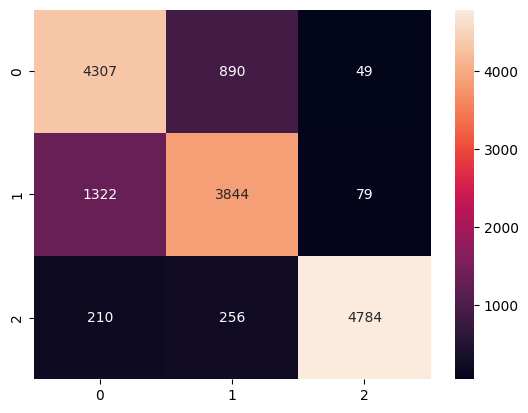

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [25]:
import re
def clean_text(text):
    text = text.lower()
    
    # fix common encoding issues
    text = text.replace("Â´", "'")
    
    # remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # remove mentions (@user)
    text = re.sub(r"@\w+", "", text)
    
    # remove hashtags symbol ONLY (#happy → happy)
    text = re.sub(r"#", "", text)
    
    return text

In [27]:
def normalize_repeats(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

In [28]:
def remove_special_chars(text):
    text = re.sub(r"[^a-zA-Z_\s]", "", text)
    return text

In [ ]:
def preprocess_pipeline(text):
    text = clean_text(text)
    text = normalize_repeats(text)
    text = remove_special_chars(text)
    return text

text = "I can actually see the effort here"
clean_textt = preprocess_pipeline(text)
clean_textt

'i can actually see the effort here'

In [30]:
seq = tokenizer.texts_to_sequences(text)
padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating = 'post')
pred = model.predict(padded)
label = np.argmax(pred, axis=1)[0]
label

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


np.int64(0)

In [ ]:
label_map = {
    0: "negative",
    1: "positive",
    2: "neutral"
    
}

In [41]:
print(predict_sentiment("I could not be happier"))

Negative Confidence : 0.9171
Neutral Confidence  : 0.0829
Positive Confidence : 0.0

Predicted Sentiment : negative
Confidence Score    : 91.71 %
('negative', np.float32(0.91713107))


In [ ]:
import pickle

# Save the model
model.save('../model/bilstm_sentiment_v1.keras')

# Save the tokenizer — THIS IS CRITICAL, people forget this
with open('../tokenizer/tokenizer_v1.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save your config so you remember exact settings
config = {
    'max_len': max_len,
    'vocab_size': vocab_size,
    'embedding_dim': embedding_dim,
    'version': 'v1_simple_sentences',
    'notes': 'BiLSTM, no lemmatization, no handle_negation, simple sentences nailed'
}

with open('config_v1.json', 'w') as f:
    import json
    json.dump(config, f, indent=2)

print("All saved.")

All saved.
